In [ ]:
import os
import glob
import pandas as pd

path = '/home/ane/dev_ws/robot/dl_study/datasets/'
dataset = {
    'image_path' : [],
    'mask_status' : [],
    'where' : []
}

for where in os.listdir(path):
    for status in os.listdir(path + '/' + where):
        for image in glob.glob(path + where + '/' + status + '/' + '*.png'):
            dataset['image_path'].append(image)
            dataset['mask_status'].append(status)
            dataset['where'].append(where)

dataset = pd.DataFrame(dataset)
dataset.head()


,image_path,mask_status,where
0,/home/ane/dev_ws/datasets/Face Mask Dataset/Te...,WithMask,Test
1,/home/ane/dev_ws/datasets/Face Mask Dataset/Te...,WithMask,Test
2,/home/ane/dev_ws/datasets/Face Mask Dataset/Te...,WithMask,Test
3,/home/ane/dev_ws/datasets/Face Mask Dataset/Te...,WithMask,Test
4,/home/ane/dev_ws/datasets/Face Mask Dataset/Te...,WithMask,Test


With Mask 5909
Without Mask 5883


<Axes: xlabel='mask_status', ylabel='count'>

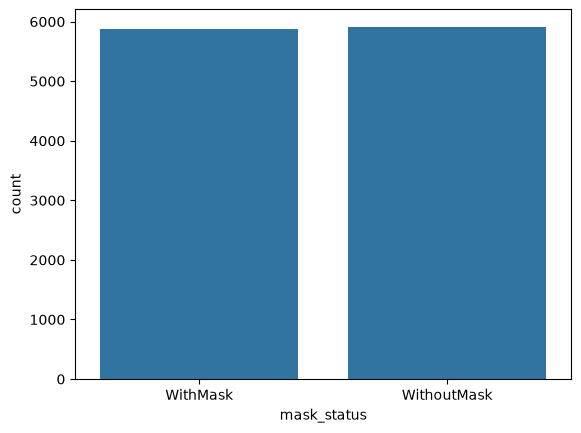

In [3]:
import seaborn as sns

print('With Mask', dataset.value_counts('mask_status').iloc[0])
print('Without Mask', dataset.value_counts('mask_status').iloc[1])

sns.countplot(x = dataset['mask_status'])

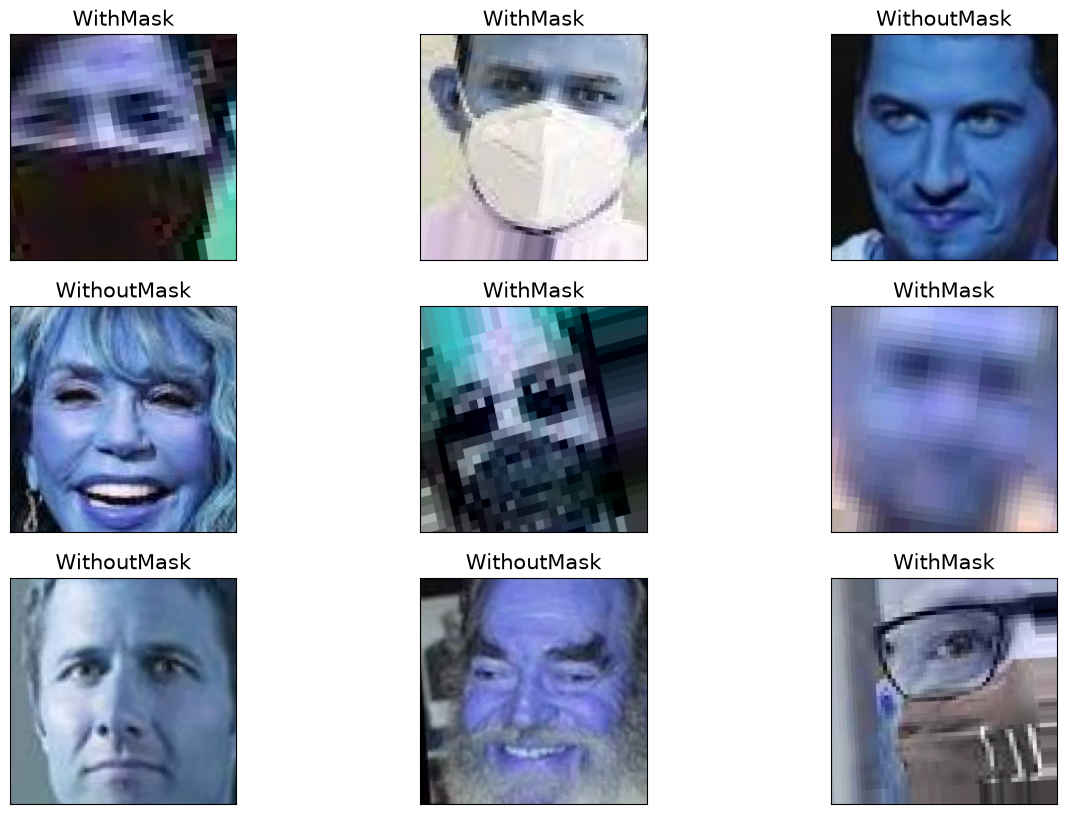

In [7]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(15,10))

for i in range(9):
    random = np.random.randint(1, len(dataset))
    plt.subplot(3, 3, i+1)
    plt.imshow(cv2.imread(dataset.loc[random, 'image_path']))
    plt.title(dataset.loc[random, 'mask_status'], size=15)
    plt.xticks([])
    plt.yticks([])
plt.show()

In [8]:
train_df = dataset[dataset['where'] == 'Train']
test_df = dataset[dataset['where'] == 'Test']
valid_df = dataset[dataset['where'] == 'Validation']

train_df.head(10)

,image_path,mask_status,where
1792,/home/ane/dev_ws/datasets/Face Mask Dataset/Tr...,WithMask,Train
1793,/home/ane/dev_ws/datasets/Face Mask Dataset/Tr...,WithMask,Train
1794,/home/ane/dev_ws/datasets/Face Mask Dataset/Tr...,WithMask,Train
1795,/home/ane/dev_ws/datasets/Face Mask Dataset/Tr...,WithMask,Train
1796,/home/ane/dev_ws/datasets/Face Mask Dataset/Tr...,WithMask,Train
1797,/home/ane/dev_ws/datasets/Face Mask Dataset/Tr...,WithMask,Train
1798,/home/ane/dev_ws/datasets/Face Mask Dataset/Tr...,WithMask,Train
1799,/home/ane/dev_ws/datasets/Face Mask Dataset/Tr...,WithMask,Train
1800,/home/ane/dev_ws/datasets/Face Mask Dataset/Tr...,WithMask,Train
1801,/home/ane/dev_ws/datasets/Face Mask Dataset/Tr...,WithMask,Train


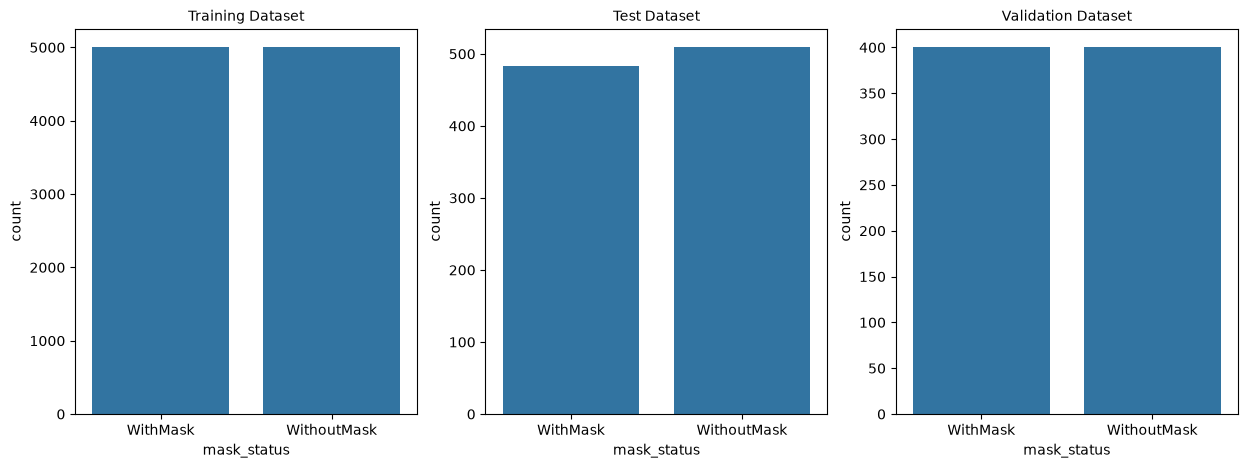

In [9]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.countplot(x = train_df['mask_status'])
plt.title('Training Dataset', size = 10)

plt.subplot(1,3,2)
sns.countplot(x = test_df['mask_status'])
plt.title('Test Dataset', size = 10)

plt.subplot(1,3,3)
sns.countplot(x = valid_df['mask_status'])
plt.title('Validation Dataset', size = 10)

plt.show()

In [10]:
train_df = train_df.reset_index().drop('index', axis=1)

In [ ]:
data = []
image_size = 150

for i in range(len(train_df)):
    img_array = cv2.imread(train_df['image_path'][i], cv2.IMREAD_GRAYSCALE)
    new_image_array = cv2.resize(img_array, (image_size, image_size))

    if train_df['mask_status'][i] == 'WithMask' :
        data.append([new_image_array, 1])
    else :
        data.append([new_image_array, 0])

In [ ]:
#data = np.array(data)
#np.random.shuffle(data)

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 2 dimensions. The detected shape was (10000, 2) + inhomogeneous part.

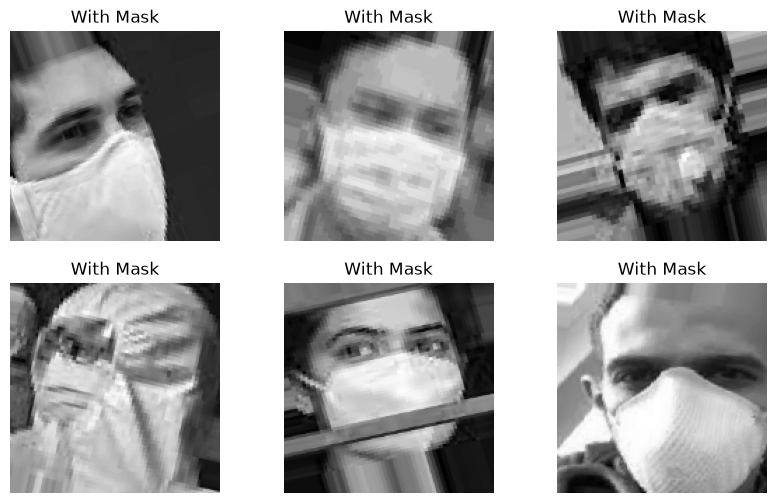

In [13]:
fig, ax = plt.subplots(2, 3, figsize=(10,6))

for row in range(2):
    for col in range(3):
        image_index = row * 100 + col

        ax[row, col].axis('off')
        ax[row, col].imshow(data[image_index][0], cmap='gray')

        if data[image_index][1] == 0 :
            ax[row, col].set_title('Without Mask')
        else:
            ax[row, col].set_title('With Mask')

In [19]:
from sklearn.model_selection import train_test_split
X = []
y = []

for image in data:
    X.append(image[0])
    y.append(image[1])

X = np.array(X)
y = np.array(y)

X_train, X_val, y_train, y_val = train_test_split(X, y,
                                                  test_size=0.2,
                                                  random_state=13)

In [22]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, kernel_size=(5,5), strides=(1,1),
                  padding='same', activation='relu',
                  input_shape=(150, 150, 1)),
    layers.MaxPooling2D(pool_size=(2,2), strides=(2,2)),
    layers.Conv2D(64, (2,2), activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=(2,2), strides=(2,2)),
    layers.Dropout(0.25),
    layers.Flatten(),
    layers.Dense(1000, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

/home/ane/tensorflow/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.BinaryCrossentropy(),
              metrics=['accuracy'])

In [26]:
X_train = X_train.reshape(len(X_train), X_train.shape[1], X_train.shape[2], 1)
X_val = X_val.reshape(len(X_val), X_val.shape[1], X_val.shape[2], 1)

his=model.fit(X_train, y_train,          
    validation_data=(X_val, y_val),  
    epochs=5,                  
    batch_size=32,               
    verbose=1           )

Epoch 1/5


W0000 00:00:1783577922.168469   47121 cpu_allocator_impl.cc:82] Allocation of 180000000 exceeds 10% of free system memory.
W0000 00:00:1783577922.417742   47121 cpu_allocator_impl.cc:82] Allocation of 180000000 exceeds 10% of free system memory.


249/250 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8918 - loss: 26.2908

W0000 00:00:1783577934.833748   47121 cpu_allocator_impl.cc:82] Allocation of 45000000 exceeds 10% of free system memory.


250/250 ━━━━━━━━━━━━━━━━━━━━ 13s 32ms/step - accuracy: 0.8920 - loss: 26.1880 - val_accuracy: 0.9410 - val_loss: 0.1973
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 0.9685 - loss: 0.0875 - val_accuracy: 0.9655 - val_loss: 0.1296
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 0.9815 - loss: 0.0530 - val_accuracy: 0.9585 - val_loss: 0.1525
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 0.9856 - loss: 0.0394 - val_accuracy: 0.9680 - val_loss: 0.1306
Epoch 5/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 0.9919 - loss: 0.0216 - val_accuracy: 0.9670 - val_loss: 0.1299


In [27]:
model.evaluate(X_val, y_val)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9670 - loss: 0.1299


[0.129913792014122, 0.9670000076293945]

In [28]:
from sklearn.metrics import classification_report, confusion_matrix

prediction = (model.predict(X_val) > 0.5).astype('int32')

print(classification_report(y_val, prediction))
print(confusion_matrix(y_val, prediction))

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1017
           1       0.97      0.96      0.97       983

    accuracy                           0.97      2000
   macro avg       0.97      0.97      0.97      2000
weighted avg       0.97      0.97      0.97      2000

[[986  31]
 [ 35 948]]


In [29]:
model2 = models.Sequential([
    layers.Conv2D(32, kernel_size=(5,5), strides=(1,1),
                  padding='same', activation='relu',
                  input_shape=(150, 150, 1)),
    layers.MaxPooling2D(pool_size=(2,2), strides=(2,2)),
    layers.Conv2D(64, (2,2), activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=(2,2), strides=(2,2)),
    layers.Dropout(0.25),
    layers.Flatten(),
    layers.Dense(1000, activation='relu'),
    layers.Dense(1,activation='sigmoid')])

/home/ane/tensorflow/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [30]:
model2.compile(optimizer='adam',
               loss=tf.keras.losses.BinaryCrossentropy(),
               metrics=['accuracy'])

In [31]:
X = []
y = []

for image in data:
    X.append(image[0])
    y.append(image[1])

X = np.array(X)
y = np.array(y)

X = X/255 # 추가

X_train, X_val, y_train, y_val = train_test_split(X, y,
                                                  test_size=0.2,
                                                  random_state=13)

X_train = X_train.reshape(len(X_train), X_train.shape[1], X_train.shape[2], 1)
X_val = X_val.reshape(len(X_val), X_val.shape[1], X_val.shape[2], 1)

history = model2.fit(X_train, y_train, epochs=5, batch_size=32)

Epoch 1/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.8870 - loss: 0.3532
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 0.9684 - loss: 0.0866
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.9793 - loss: 0.0550
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.9839 - loss: 0.0425
Epoch 5/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.9883 - loss: 0.0322


In [32]:
model2.evaluate(X_val,y_val)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9780 - loss: 0.0783


[0.07833943516016006, 0.9779999852180481]

In [33]:
wrong_result = []

for n in range(0, len(y_val)):
    if prediction[n] != y_val[n]:
        wrong_result.append(n)

len(wrong_result)

66

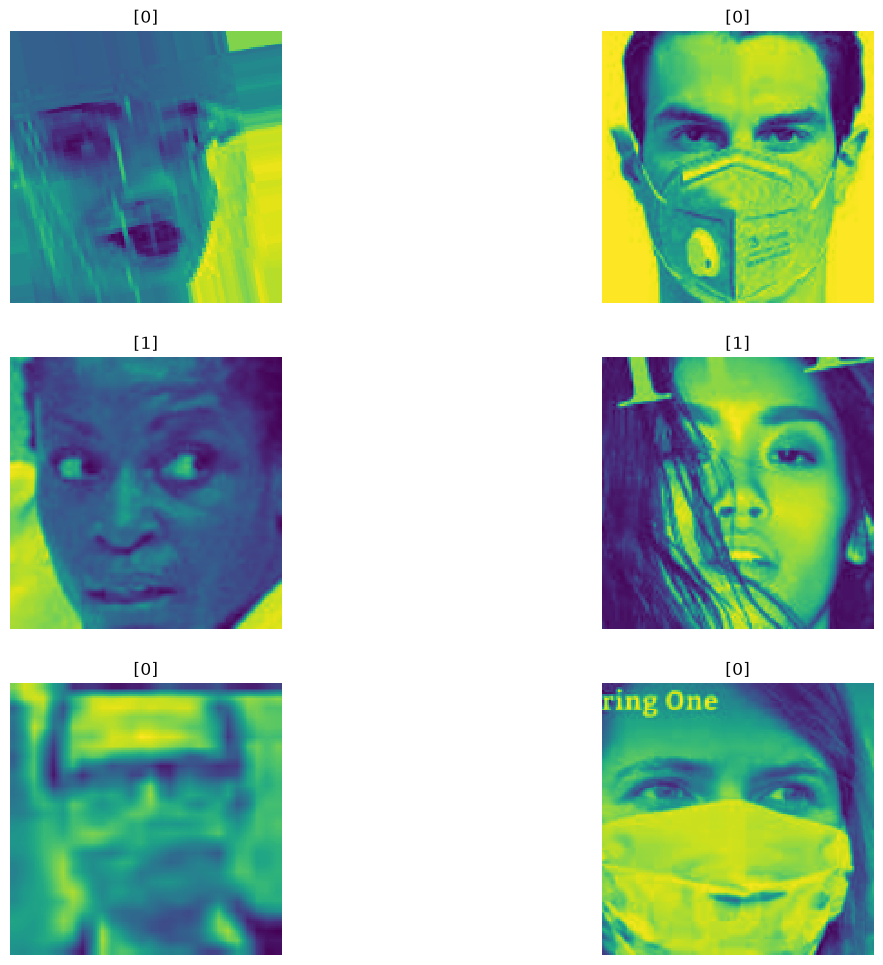

In [34]:
import random
samples = random.choices(population=wrong_result, k=6)

plt.figure(figsize=(14,12))

for idx, n in enumerate(samples):
    plt.subplot(3, 2, idx+1)
    plt.imshow(X_val[n].reshape(150,150), interpolation='nearest')
    plt.title(prediction[n])
    plt.axis('off')
plt.show();